In [1]:
import os
import json
import random
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

In [2]:
BASE_DIR = "../smartvision_dataset"

with open(f"{BASE_DIR}/dataset_metadata.json", "r") as f:
    metadata = json.load(f)

metadata

{'total_images': 0,
 'classes': {'person': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'bicycle': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'car': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'motorcycle': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'airplane': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'bus': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'truck': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'traffic light': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'stop sign': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'bench': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'bird': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'cat': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'dog': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'horse': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'cow': {'train': 70, 'val': 15, 'test': 15, 'total': 100},
  'elephant'

In [3]:
class_df = pd.DataFrame(metadata["classes"]).T
class_df

,train,val,test,total
person,70,15,15,100
bicycle,70,15,15,100
car,70,15,15,100
motorcycle,70,15,15,100
airplane,70,15,15,100
bus,70,15,15,100
truck,70,15,15,100
traffic light,70,15,15,100
stop sign,70,15,15,100
bench,70,15,15,100


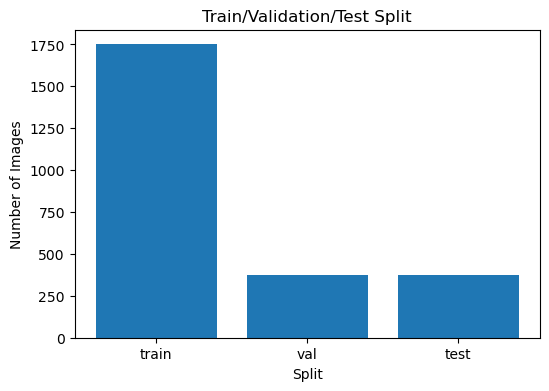

In [4]:
splits = metadata["splits"]

plt.figure(figsize=(6,4))
plt.bar(splits.keys(), splits.values())
plt.title("Train/Validation/Test Split")
plt.xlabel("Split")
plt.ylabel("Number of Images")
plt.show()

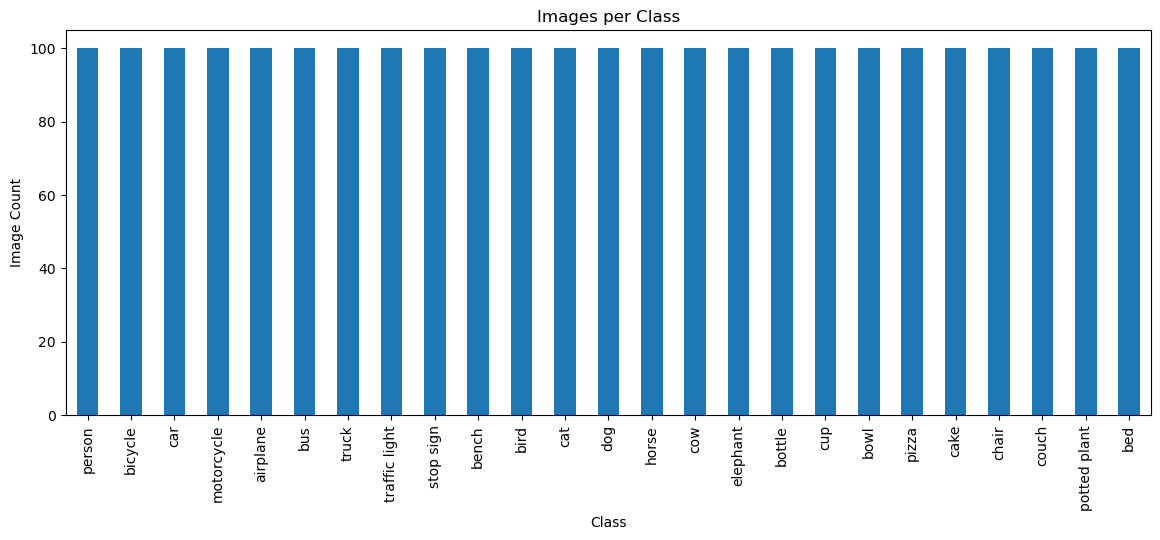

In [5]:
class_df["total"].plot(kind="bar", figsize=(14,5))
plt.title("Images per Class")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=90)
plt.show()

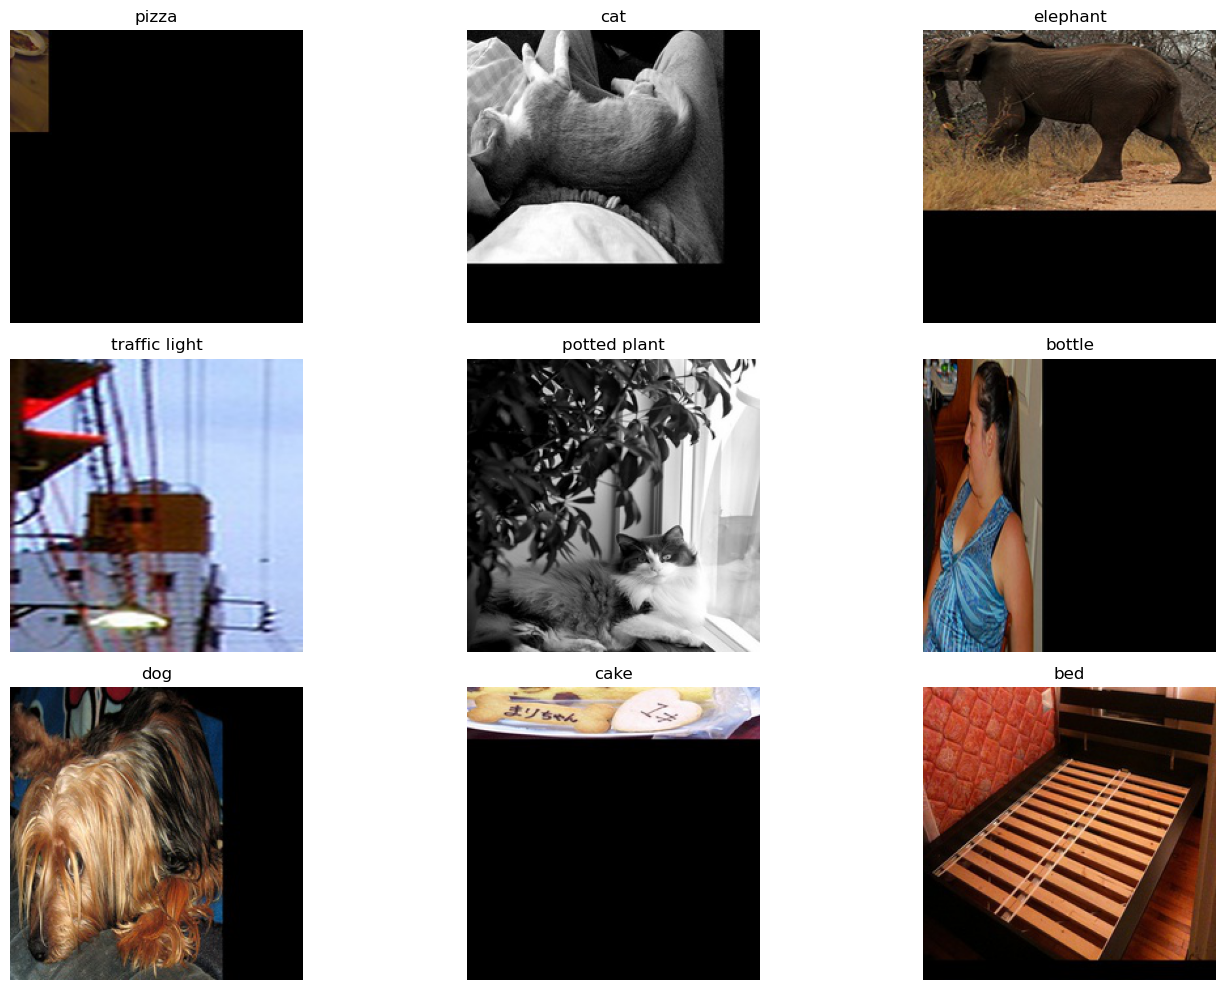

In [6]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_path = "../smartvision_dataset/classification/train"

classes = os.listdir(train_path)

plt.figure(figsize=(15,10))

for i in range(9):
    class_name = random.choice(classes)

    img_file = random.choice(
        os.listdir(os.path.join(train_path, class_name))
    )

    img_path = os.path.join(
        train_path,
        class_name,
        img_file
    )

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
print("="*50)
print("DATASET SUMMARY")
print("="*50)

print("Total Images :", metadata["total_images"])

print("\nTrain Images :", metadata["splits"]["train"])
print("Validation Images :", metadata["splits"]["val"])
print("Test Images :", metadata["splits"]["test"])

print("\nNumber of Classes :", len(metadata["classes"]))

print("="*50)

DATASET SUMMARY
Total Images : 0

Train Images : 1750
Validation Images : 375
Test Images : 375

Number of Classes : 25


In [8]:
print(metadata.keys())

dict_keys(['total_images', 'classes', 'splits', 'classification', 'detection', 'dataset_path'])


In [9]:
print(metadata["total_images"])

0


In [10]:
total_images = (
    metadata["splits"]["train"]
    + metadata["splits"]["val"]
    + metadata["splits"]["test"]
)

print("Total Images :", total_images)
print("Train Images :", metadata["splits"]["train"])
print("Validation Images :", metadata["splits"]["val"])
print("Test Images :", metadata["splits"]["test"])
print("Number of Classes :", len(metadata["classes"]))

Total Images : 2500
Train Images : 1750
Validation Images : 375
Test Images : 375
Number of Classes : 25


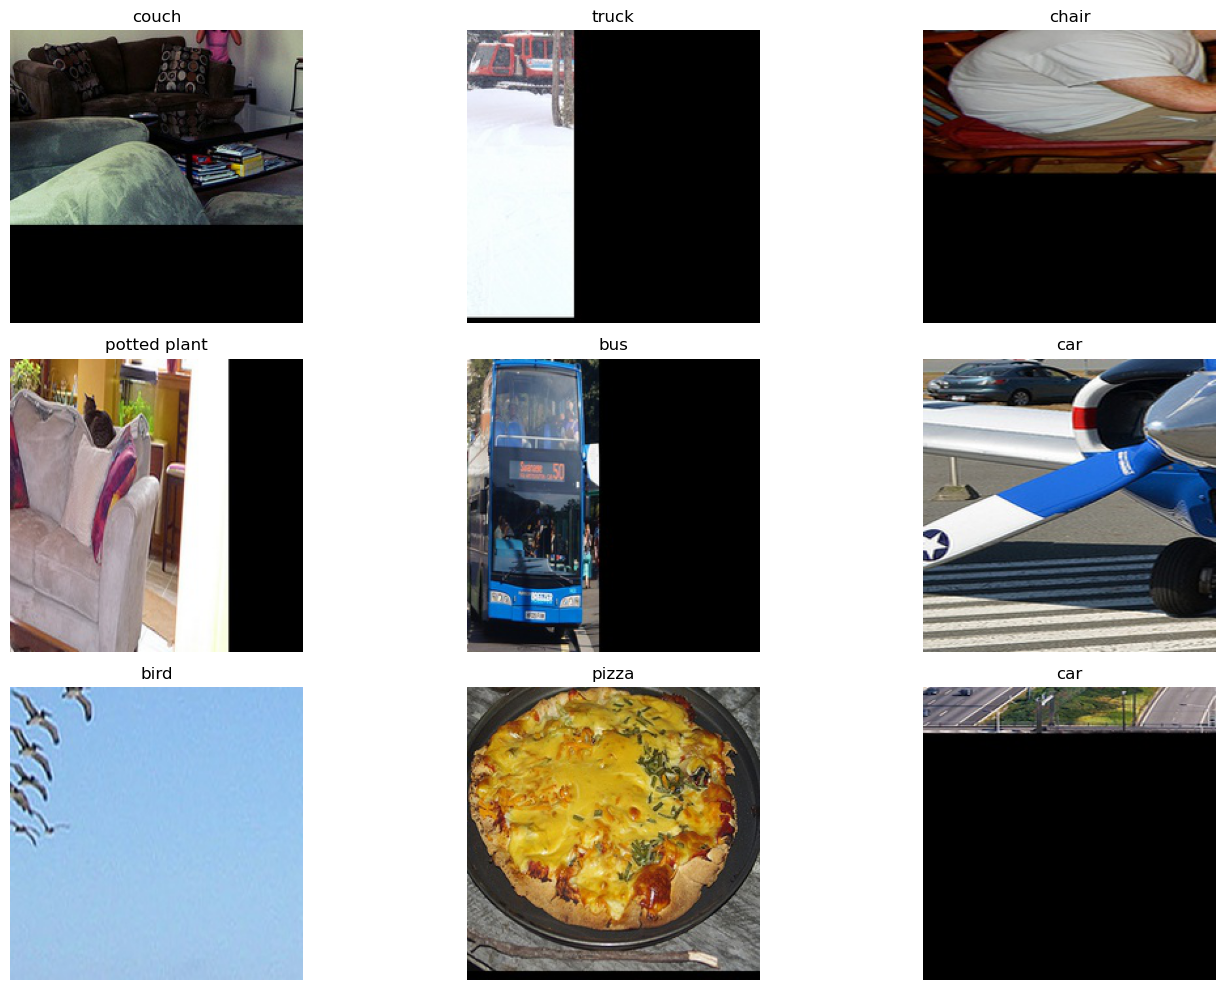

In [11]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_path = "../smartvision_dataset/classification/train"

classes = os.listdir(train_path)

plt.figure(figsize=(15,10))

for i in range(9):
    class_name = random.choice(classes)

    img_file = random.choice(
        os.listdir(os.path.join(train_path, class_name))
    )

    img_path = os.path.join(train_path, class_name, img_file)

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

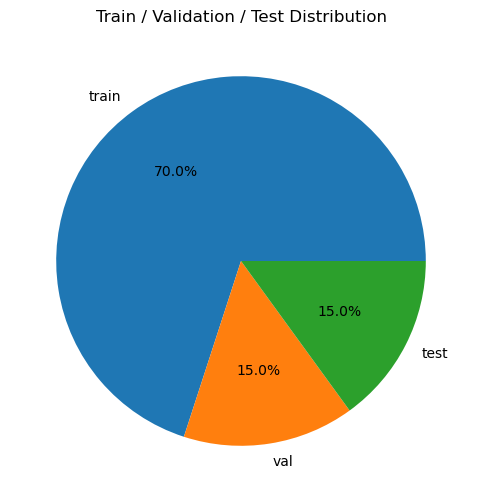

In [12]:
splits = metadata["splits"]

plt.figure(figsize=(6,6))

plt.pie(
    splits.values(),
    labels=splits.keys(),
    autopct='%1.1f%%'
)

plt.title("Train / Validation / Test Distribution")
plt.show()

In [13]:
sample_sizes = []

for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)

    for img_file in os.listdir(class_folder)[:5]:
        img = Image.open(
            os.path.join(class_folder, img_file)
        )

        sample_sizes.append(img.size)

pd.DataFrame(
    sample_sizes,
    columns=["Width","Height"]
).describe()

,Width,Height
count,125.0,125.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0
